In [15]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import string
import os
import glob
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
import matplotlib.dates as mdates


In [34]:
f = '/storage/experiments/2024/0727_bourka_sobeslav/thundermill/nerezlog_20240728_012024_UTC.csv'
f = '/storage/experiments/2025/0515_thundermill_test/EFM_THUNDERMILL01log_20250516_175300_UTC.csv'
f = '/storage/experiments/2025/0521_bourka_velemin/thundermill/EFM_THUNDERMILL01log_20250521_102432_UTC.csv'

l=[]
l.extend(range(0,113))
df = pd.read_table(f, sep=',', names=l, header=None, comment='*',engine='python', on_bad_lines='skip' )


In [38]:
df['time'] = pd.to_datetime(df[0], unit='s')
df.set_index('time', inplace=True, drop=False)

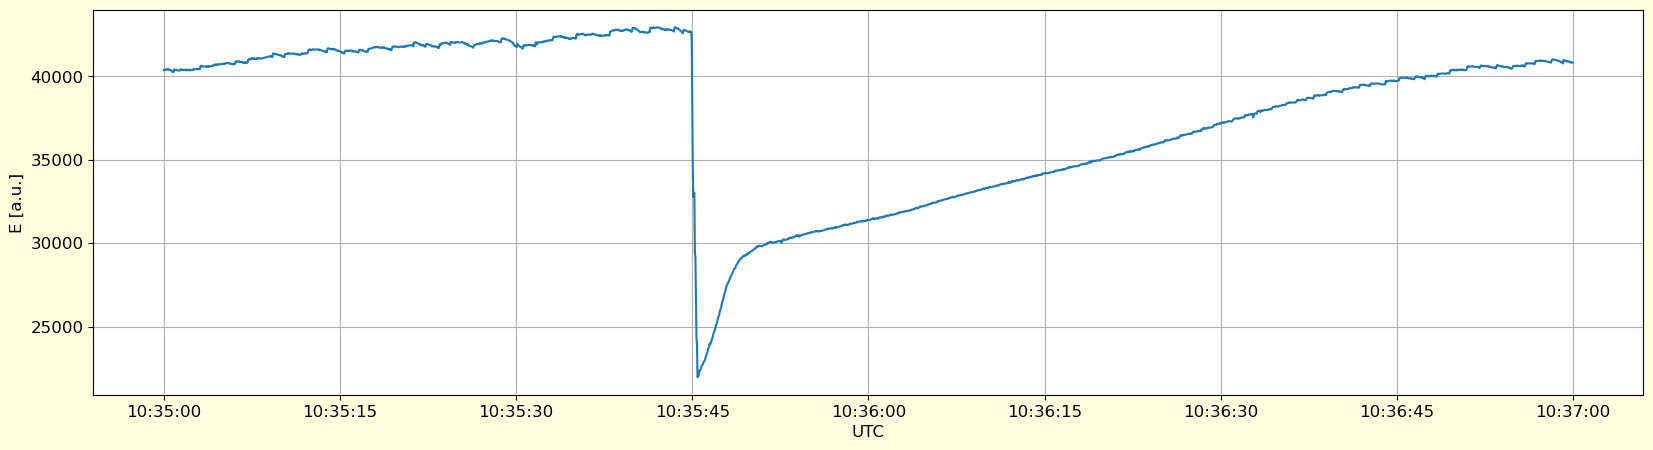

In [108]:
plt.figure(figsize=(20,5), facecolor='lightyellow')
plt.rc('font', size=12)    

df['mean'] = df[15].rolling(1).mean()
#df['mean'] = df.iloc[:,20:30].mean(axis=1)
#df['mean'] = df.iloc[:,1:].max(axis=1)-df.iloc[:,1:].min(axis=1)

#plt.plot(df.loc['2024-05-16 18:00':'2024-07-03 19:40','mean'])
plt.plot(df.loc['2025-05-21 10:35':'2025-05-21 10:36','mean'])
#plt.plot(df.loc['2025-05-21 10:46:03':'2025-05-21 10:46:05','mean'])
#plt.plot(df['mean'])
#plt.ylim(33000,33600)
plt.xlabel('UTC')
plt.ylabel('E [a.u.]')
plt.grid()
thundermill = df.copy()

Text(0.5, 1.0, '2025-05-21 10:46:03.550000')

<Figure size 2000x1000 with 0 Axes>

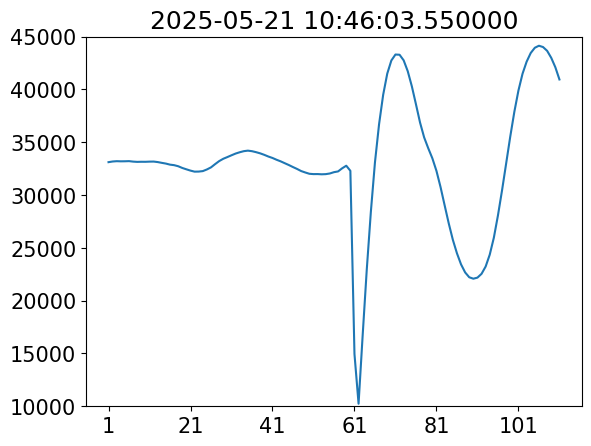

In [78]:
plt.figure(figsize=(20,10), facecolor='lightyellow')
matplotlib.rcParams.update({'font.size': 15})

TIME = pd.to_datetime('2025-05-21 10:46:03.55')
TIMEEND = TIME + pd.to_timedelta(0.05, 's')

mask = (df.index >= TIME) & (df.index <= TIMEEND)

df_filtered = df.loc[mask].iloc[:,1:112]  # Pozor: konec slice je exkluzivní
df_filtered.T.plot(legend=None)
plt.ylim(10000,45000)
plt.title(TIME)


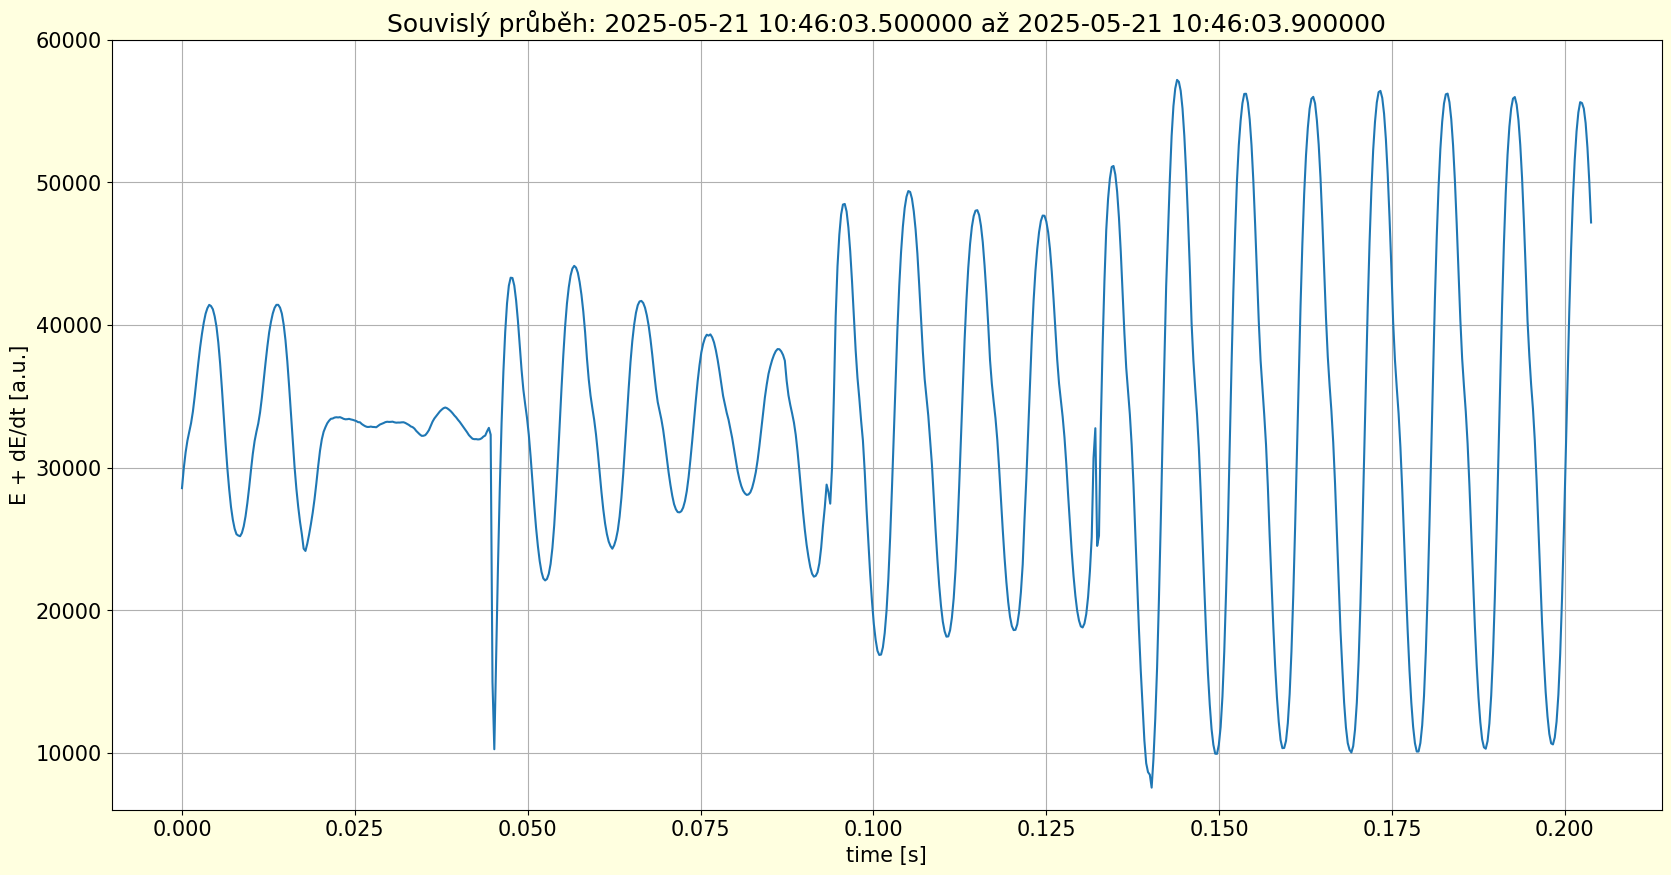

In [132]:
plt.figure(figsize=(20, 10), facecolor='lightyellow')
matplotlib.rcParams.update({'font.size': 15})

TIME = pd.to_datetime('2025-05-21 10:46:03.5')
#TIME = pd.to_datetime('2025-05-21 10:35:44.9')
TIMEEND = TIME + pd.to_timedelta(0.4, 's')

mask = (df.index >= TIME) & (df.index <= TIMEEND)
df_filtered = df.loc[mask].iloc[:, 1:112]  # vybereme 111 sloupců

# 1️⃣ Srovnáme hodnoty do jednoho vektoru
long_series = df_filtered.values.flatten()  # seřadí všechny řádky za sebou

# 2️⃣ Pokud znáš vzorkovací frekvenci (např. 1000 Hz), dopočítáme časovou osu
fs = 34*112  # Hz, příklad
t = np.arange(len(long_series)) / fs

# 3️⃣ Vykreslení
plt.plot(t, long_series)
plt.ylim(6000, 60000)
plt.xlabel("time [s]")
plt.ylabel("E + dE/dt [a.u.]")
plt.title(f"Souvislý průběh: {TIME} až {TIMEEND}")
plt.grid(True)
plt.show()

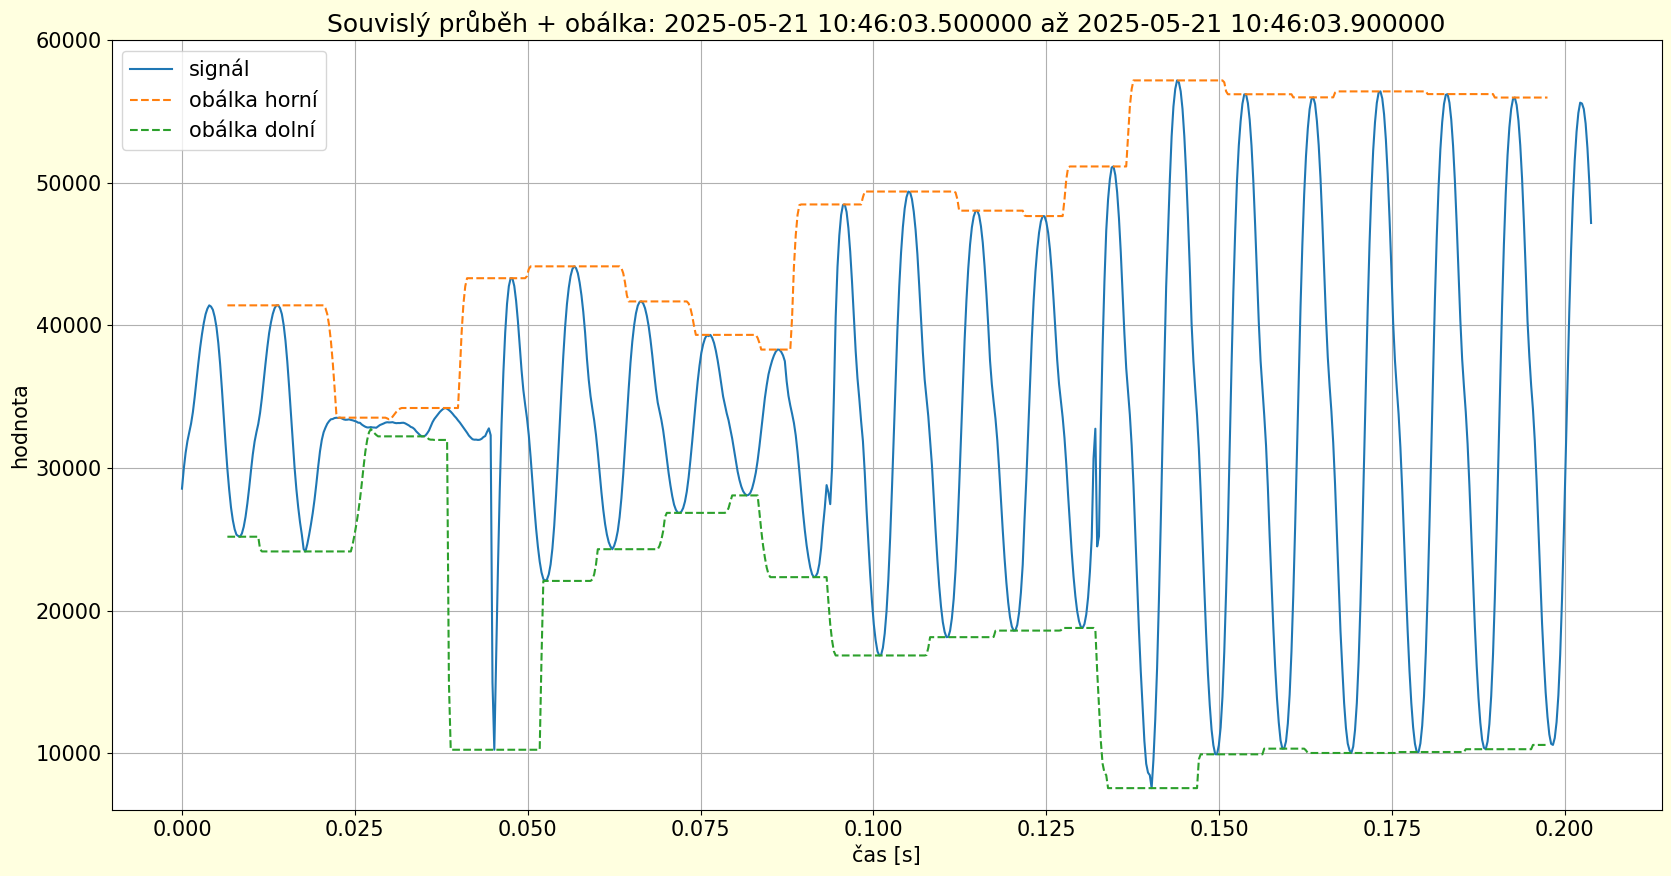

In [134]:
import scipy.signal

# Výpočet obálky: klouzavé maximum
window_size = 50  # počet vzorků pro vyhlazení
upper_envelope = pd.Series(long_series).rolling(window_size, center=True).max()
lower_envelope = pd.Series(long_series).rolling(window_size, center=True).min()

# Vykreslení signálu a obálky
plt.figure(figsize=(20, 10), facecolor='lightyellow')
plt.plot(t, long_series, label='signál')
plt.plot(t, upper_envelope, label='obálka horní', linestyle='--')
plt.plot(t, lower_envelope, label='obálka dolní', linestyle='--')
plt.ylim(6000, 60000)
plt.xlabel("time [s]")
plt.ylabel("hodnota")
plt.title(f"Souvislý průběh + obálka: {TIME} až {TIMEEND}")
plt.legend()
plt.grid(True)
plt.show()

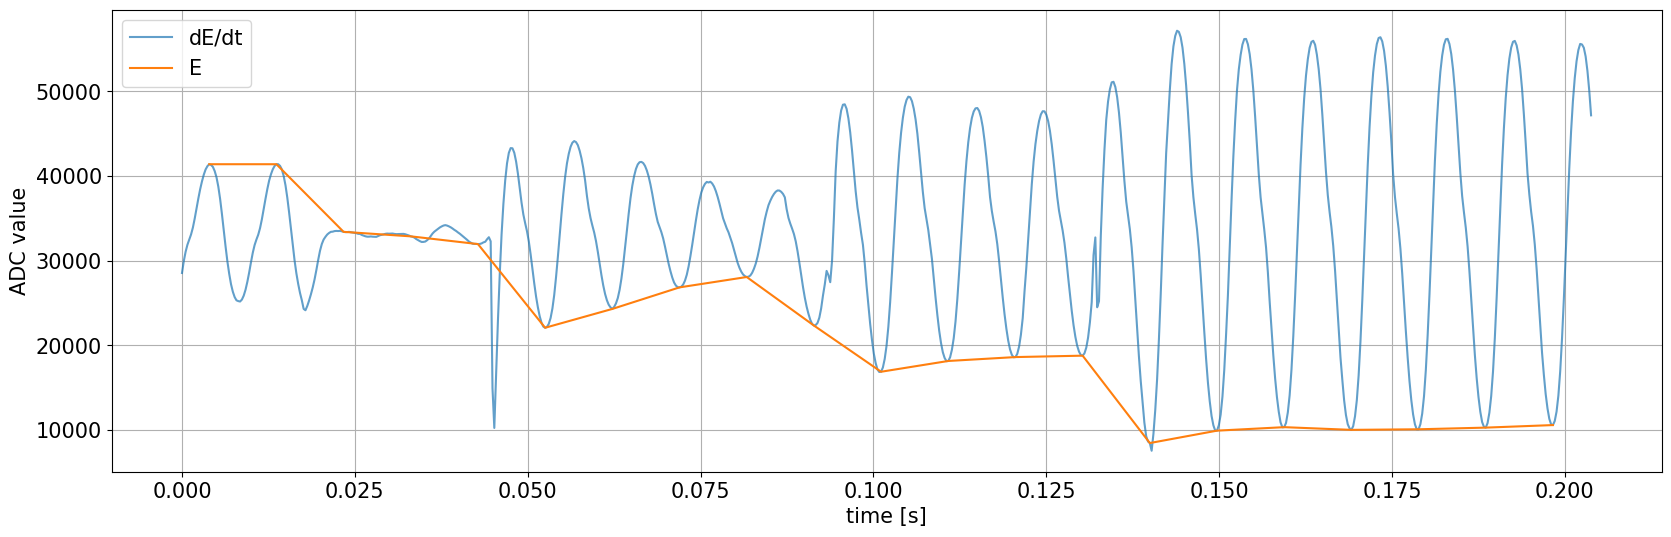

In [169]:
import numpy as np
import matplotlib.pyplot as plt

fs = 34*112   # Hz
cols = [15, 52, 89]  # sloupce 15, 52, 89
labels = ['15', '52', '89']

# 1️⃣ Původní kontinuální signál
long_series = df_filtered.values.flatten()
t_long = np.arange(len(long_series)) / fs  # přesná časová osa

# 2️⃣ Vybrané body a jejich časy
times_selected = []
values_selected = []

rows = df_filtered.shape[0]
samples_per_row = df_filtered.shape[1]

for i in range(rows):
    for c in cols:
        t = (i * samples_per_row + c) / fs
        v = df_filtered.iloc[i, c]
        times_selected.append(t)
        values_selected.append(v)

# 3️⃣ Vykreslení
plt.figure(figsize=(20, 6))

# Signál
plt.plot(t_long, long_series, label='dE/dt', alpha=0.7)

# Vybrané body
plt.plot(times_selected, values_selected, label='E', markersize=4)

plt.xlabel("time [s]")
plt.ylabel("ADC value")
#plt.title("Souvislý signál + správně umístěné body 15, 52, 89")
plt.legend()
plt.grid(True)
plt.show()
